In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil',
    'Oil': 'Fossil',
    'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon',
    'Hydro': 'Low-carbon',
    'Wind': 'Renewable',
    'Solar': 'Renewable',
    'Other Renewables': 'Renewable'
}

df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


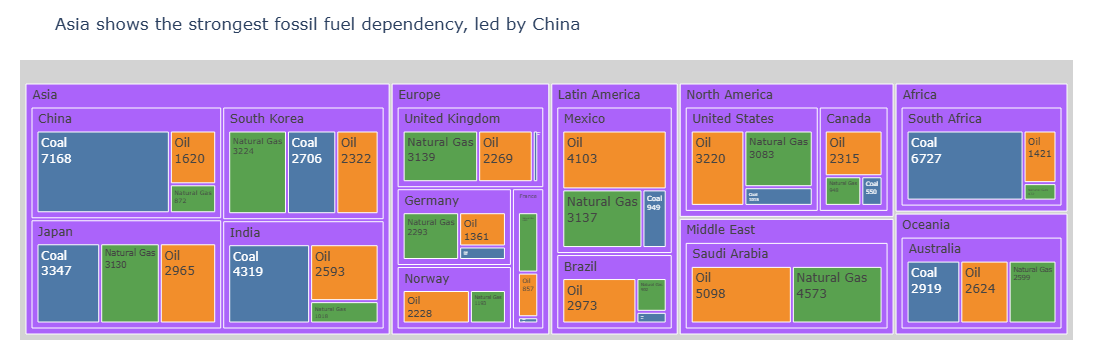

In [2]:
#Task1 Filter fossil fuel sources only
fossil_df = df.loc[df['Source_Type'] == 'Fossil'].copy()

# Aggregate TWh
fossil_grouped = (
    fossil_df
    .groupby(['Region', 'Country', 'Source'])['TWh']
    .sum()
    .reset_index()
)

# CVD-safe palette
fossil_colors = {
    'Coal': '#4E79A7',
    'Oil': '#F28E2B',
    'Natural Gas': '#59A14F'
}

# Treemap
fig = px.treemap(
    fossil_grouped,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_colors,
    title='Asia shows the strongest fossil fuel dependency, led by China'
)

# Grey out parent nodes
fig.update_traces(
    root_color='lightgrey',
    textinfo='label+value'
)

fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

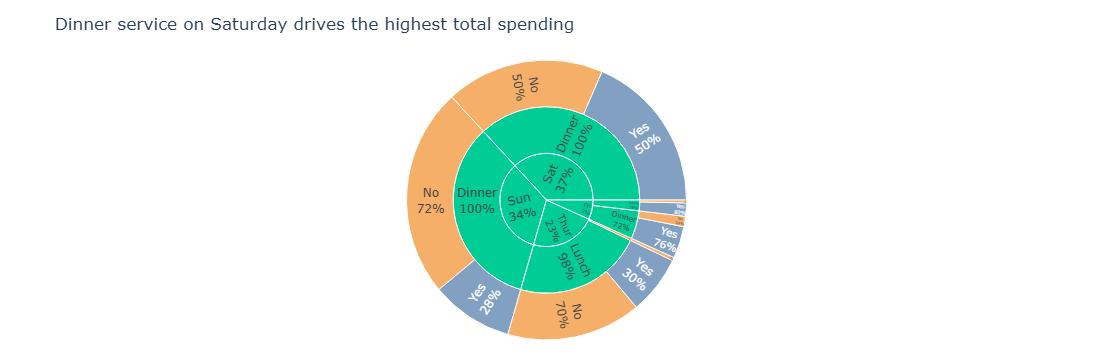

In [4]:
#task2 Sunburst: tipping behaviour by day and meal time
tips = px.data.tips()

# Aggregate total bill amount
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# CVD-safe palette
tip_colors = {
    'Yes': '#4E79A7',
    'No': '#F28E2B'
}

# Sunburst chart
fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=tip_colors,
    title='Dinner service on Saturday drives the highest total spending'
)

# Grey out parent nodes
fig.update_traces(
    insidetextorientation='radial',
    textinfo='label+percent parent',
    root_color='lightgrey'
)

fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

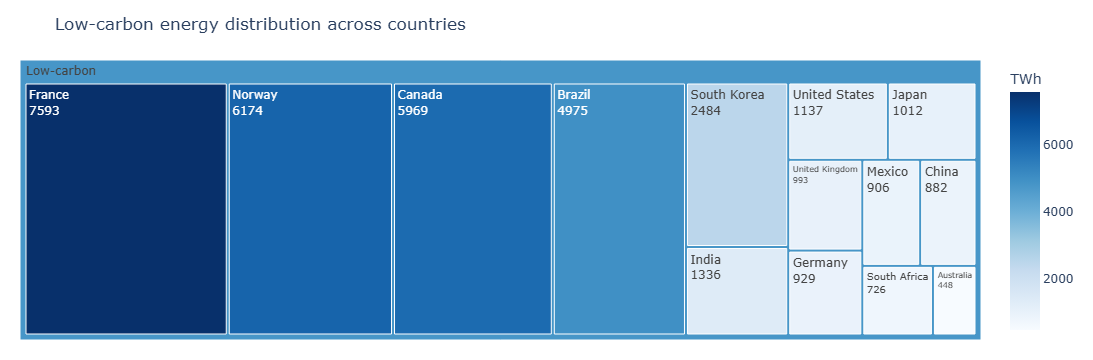

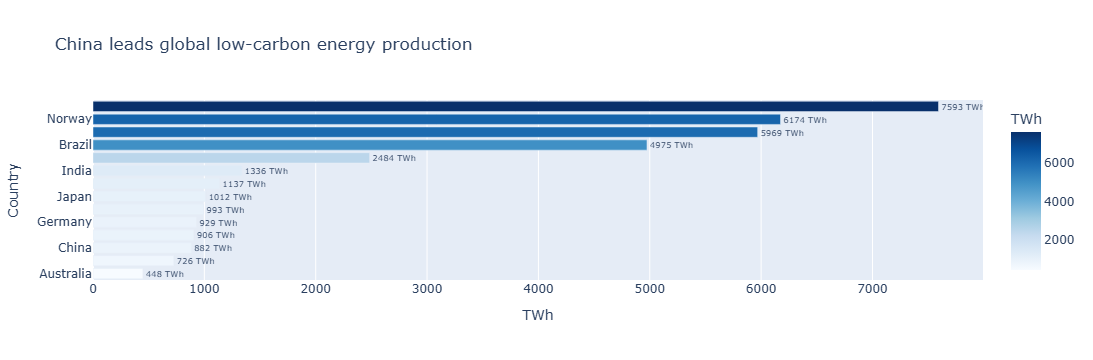

In [5]:
#Task 3 — Treemap vs bar: low-carbon energy by country Filter low-carbon sources
low_carbon_df = df.loc[df['Source_Type'] == 'Low-carbon'].copy()

# Aggregate TWh by country
low_carbon_grouped = (
    low_carbon_df
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Add dummy root node
low_carbon_grouped['All'] = 'Low-carbon'

# ---------- Treemap ----------
fig_tree = px.treemap(
    low_carbon_grouped,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-carbon energy distribution across countries'
)

fig_tree.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig_tree.update_layout(
    margin=dict(t=60, l=20, r=20, b=20)
)

fig_tree.show()

# ---------- Horizontal Bar Chart ----------
low_carbon_sorted = low_carbon_grouped.sort_values(
    by='TWh',
    ascending=True
)

fig_bar = px.bar(
    low_carbon_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    title='China leads global low-carbon energy production'
)

fig_bar.update_traces(
    texttemplate='%{x:.0f} TWh',
    textposition='outside'
)

fig_bar.update_layout(
    yaxis_title='Country',
    xaxis_title='TWh',
    showlegend=False
)

fig_bar.show()